# Einleitung

Dieses Projekt analysiert globale Wildfires anhand satellitenbasierter Daten des NASA FIRMS Systems.
Der Fokus liegt auf der Untersuchung der räumlichen Verteilung, der Intensität und Detektionssicherheit von Wildfires innerhalb eines kurzen Zeitraums (letzte 24 Stunden). Der Datensatz liegt im .csv Format vor (abgerufen am 19.05.2026) und enthält georeferenzierte Punktdaten, wobei jede Zeile ein detektiertes Wildfire repräsentiert.
Wichtige Variablen wie die geografische Lage (Latitude/Longitude), die Detektionssicherheit (confidence) sowie die Feuerintensität (Fire Radiative Power, FRP) werden genutzt, um die Verteilung und Eigenschaften der Brände zu analysieren.

Das **Ziel** dieses Projekts ist es, eine automatisierte Pipeline zu entwickeln, die Wildfires verarbeitet, relevante Informationen herausfiltert, eine gezielte Analyse ermöglicht und die Ergebnisse übersichtlich auf einer interaktiven Karte visualisiert.

Die **Forschungsfrage**, die mit diesem Projekt beantwortet werden soll, ist: *Wie sind die globalen Wildfire-Ereignisse der letzten 24 Stunden räumlich verteilt und welche Aussagen lassen sich über deren Intensität und Detektionssicherheit treffen?* Zur Beantwortung dieser Forschungsfrage werden folgende **Teilaspekte** untersucht:

* **Räumliche Verteilung**: Wie sind die Wildfire-Ereignisse weltweit verteilt?
* **Intensität**: Wie verteilt sich die Feuerintensität (Fire Radiative Power, FRP)?
* **Top-Ereignisse**: In welchen Ländern traten die die 10 stärksten Wildfires auf?
* **Datenqualität**: Wie verteilt sich die Detektionssicherheit (confidence) über die erfassten Wildfires?
* **Statistische Analyse**: Welche statistischen Aussagen lassen sich aus der Verteilung der Intensität ableiten?
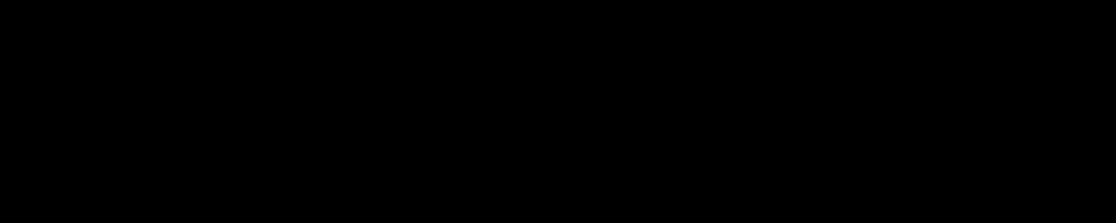

### Schritt 1: Vorbereitung

##### 1.1. Importe, Pfade und Rohdaten einlesen

In [ ]:
#Importe
from pathlib import Path #hilft beim Arbeiten mit Datei- und Ordnerpfaden
import sys #Zugriff auf systembezogene Funktionen
sys.path.append("..") #Fügt das übergeordnete Verzeichnis zum Suchpfad hinzu, damit eigene Module importiert werden können
import pandas as pd #Bibliothek für Datenanalyse (Tabellen, DataFrames, CSV-Dateien etc.)
import geopandas as gpd #Erweiterung von pandas für räumliche Daten (Geometrien, Shapefiles, Karten)
from scripts.spatial_tools import reverse_geocode_coordinates #Eigene Funktion: wandelt Koordinaten (Lat/Lon) in Ortsnamen um (Reverse Geocoding)
from scripts.classification import classify_fire_intensity #Eigene Funktion: klassifiziert Brandintensität (frp)
import matplotlib.pyplot as plt #Bibliothek zum Erstellen von Diagrammen und einfachen Visualisierungen

#Pfade
data_dir = Path("../data") #heisst "gehe eine Orderstruktur höher" und dann in "data"
raw_dir = data_dir / "raw" #wo der Rohdatenordner zu finden ist
processed_dir = data_dir / "processed" #wo der Ordner mit den verarbeiteten Rohdaten ist
output_dir = Path("../outputs") #wo die zu exportierenden Karten und Grafiken hinkommen
csv_path = raw_dir / "SUOMI_VIIRS_C2_Global_24h.csv" #wo das unverarbeitete CSV abgelegt ist

#Rohdaten laden
df = pd.read_csv(csv_path) #liest das .csv als pandas DataFrame ein
type(df) #zeigt den Datentyp von df an (zur Kontrolle)


**Zusammenfassung Schritt 1.1.:** Zunächst haben wir die benötigten Importe vorgenommen, Pfade definiert und das Rohdaten csv als pandas DataFrame reingeladen (_pd.read_csv()_).

##### 1.2. Inhalte anzeigen und Überblick verschaffen

In [ ]:
print("Die ersten 5 Zeilen des DataFrames:")
print(df.head()) #zeigt die ersten 5 Zeilen des DataFrames an

print("\nÜbersicht zu den Datentypen im DataFrame:")
print(df.info()) #gibt eine Übersicht zu den Datentypen im DataFrame aus

**Zusammenfassung Schritt 1.2.:** Anschliessend haben wir uns die Inhalte dieser Rohdaten anzeigen lassen: _data.head()_ gibt uns die ersten 5 Reihen des DataFrames aus. Daraus können wir ableiten, dass für die Forschungsfrage lediglich die Spalten "latitude", "longitude", "acq_date", "confidence" und "frp" relevant sind. Daher selektieren wir diese in Schritt 2. Die Spaltentitel sollten ausserdem noch etwas verständlicher unbenannt werden. Dafür stütze ich mich auf die Informationen im User Guide de NASA (2018) (siehe Quellen am Schluss). Zudem hat uns _data.info()_ gezeigt, dass acq_date momentan noch ein String ist. Das müssen wir ebenfalls ändern und in ein Datumformat umwandeln.

### Schritt 2: Bereinigung der Rohdaten

##### Schritt 2.1. Reduzierung des originalen DataFrames und Überprüfung auf fehlende Werte (NaN)

In [ ]:
relevant_data = df[["latitude", "longitude", "acq_date", "confidence", "frp"]].copy() #relevante Spalten auswählen und eine echte Kopie herstellen vom original dataframe
print("Reduzierter DataFrame:")
print(relevant_data.head()) #zeigt die ersten 5 Zeilen des reduzierten DataFrames an (zur Kontrolle)
print("\nÜberprüfung fehlender Werte (NaN):")
print(relevant_data.isna().sum()) #zählt NaNs pro Spalte im Dataframe


**Zusammenfassung Schritt 2.1.** Vom ursprünglichen DataFrame selektieren wir nun nur jene Spalten, die für uns interessant sind (_"latitude", "longitude", "acq_date", "confidence", "frp"_). Von unserer Selektion des ursprünglichen Dataframes machen wir zudem eine Kopie (_.copy()_), um Komplikationen bei späteren Modifikationen an unserem Subset zu verhindern. *relevant_data.isna().sum()* hat ergeben, dass es bei unserem Datensatz keine fehlenden Werte gibt. Daher müssen wir an dieser Stelle nichts bereinigen.

##### Schritt 2.2. Neue Spaltenbezeichnungen und Umwandlung Detektionsdatum

In [ ]:
#Spaltenbezeichnunge unbenennen:
relevant_data = relevant_data.rename(columns={
    "latitude": "lat",
    "longitude": "lon",
    "acq_date": "detection_date",
    "confidence": "detection_confidence",
    "frp": "fire_radiative_power"
})

print("\nReduzierter DataFrame mit neuen Spaltenbezeichnungen:")
print(relevant_data.head())

relevant_data["detection_date"] = pd.to_datetime(relevant_data["detection_date"]) #detection_date von string in ein Datum umwandeln
print("\nKontrolle Datentypen:")
print(relevant_data.info()) #schauen ob der string erfolgreich in ein Datum umgewandelt wurde


relevant_data.to_csv(processed_dir / "relevant_data.csv", index=False) #export der relevanten Daten als .csv in den "processed" Ordner

**Zusammenfassung Schritt 2.2:** Wir haben die Spaltenbezeichnungen unbenannt (_relevant_data.rename()_), damit sie sofort für jeden klar sind. Hier bei habe ich mich auf den User Guide (NASA, 2018) gestützt. Laut dem sind die Header wie folgt zu interpretieren:
* detection_date = YYYYMMDD Erfassungsdatum in year (YYYY), month (MM) and day (DD)
* detection_confidence =  Branderkennungs-Konfidenz (“L”=low, “N”=nominal, “H”=high)
* fire_radiative_power Strahlungsleistung des Feuers in megawatt (Mass für thermische Intensität)

Das _detection_date_, das bisher noch als string erfasst war, wurde jetzt ausserdem in ein Datum umgewandelt (_pd.to_datetime()_).

Zur Kontrolle werden am Schluss nachmals alle Datentypen der reduzierten DataFrames angezeigt (_info()_).

## Schritt 3: Datenanalyse

##### 3.1. Statistische Übersicht der Feuerintensitäten (FRP)

In [ ]:
print("Die statistische Übersicht der Feuerintensität (FRP) der letzten 24h:")
print(relevant_data["fire_radiative_power"].describe())

**Zusammenfassung Schritt 3.1.:** Die statistische Übersicht _(.describe())_ zeigt uns, dass es in den letzten 24h insgesamt 39787 Brandereignisse _(count)_ Weltweit gab. Davon weisen die meisten Waldbrände eine geringe Intensität (Werte in megawatt (MW)) auf. Der Median liegt bei 4.73 MW (Wert bei 50%), während der Durchschnitt (mean) durch wenige sehr starke Brände erhöht wird. Der hohe Maximalwert von 601.15 MW sowie die grosse Streuung (std) deuten auf einzelne extreme Ereignisse hin, während der Grossteil der Brände eher schwach ist.

##### 3.2. Histogramm: Verteilung der Feuerintensität

In [ ]:
print("Histogramm der Verteilung der Feuerintensität:")
relevant_data["fire_radiative_power"].hist(bins=50) #Histogramm mit 50 Klassen
plt.xlabel("Fire Radiative Power (FRP)") #Bezeichnung x-Achse
plt.ylabel("Anzahl Brände") #Bezeichnung y-Achse
plt.title("Verteilung der Feuerintensität") #Titel

plt.savefig(output_dir / "histogram_fire_intensity.png", dpi=300, bbox_inches="tight") #export des histogramms als png in den output-Ordner, dpi (Dots per Inch) entspricht der Auflösung, bbox_inches="tight" Schneidet den überschüssigen Randbereich um die Abbildung automatisch ab, sodass das exportierte Bild genau an die Ränder der Grafik angepasst wird.
plt.show() #Histogramm anzeigen

relevant_data["intensity_class"] = relevant_data["fire_radiative_power"].apply(classify_fire_intensity) #dem DataFrame wird eine neue Spalte "intensity_class" hinzugefügt.
counts = relevant_data["intensity_class"].value_counts() #Zählung der Werte pro Intensitätsklasse

print("Anzahl Brände pro Intensitätsklasse:")
print(counts)

**Zusammenfassung Schritt 3.2**: Zunächst wurde ein Histogramm mit maximal 50 Klassen erstellt, um sich die Verteilung der Feuerintensität über die detektieren Brandereignisse besser vorstellen zu können (_.hist(bins=50)_). Das Histogramm zeigt deutlich, dass die Mehrheit der Wildfires eine geringe Fire Radiative Power (FRP) aufweist, während nur wenige Ereignisse sehr hohe Intensitätswerte erreichen. Diese rechtsschiefe Verteilung bestätigt die zuvor berechneten Kennzahlen, insbesondere den niedrigen Median im Vergleich zum Maximum, und verdeutlicht das Vorhandensein von Ausreissern mit sehr hoher Intensität. Das Histogramm wird anschliessend in der Output-Ordner exportiert (_plt.savefig()_).

Die Verteilung wird weiter bestätigt durch die Zählung der Anzahl Brände pro Intensitätsklasse (_.value_counts()_). Die Klassen wurde gem. ArcGIS Fire Radiative Power Erklärung https://experience.arcgis.com/experience/a0dcc4b8e8ab49b58a520f5acb983345/page/FIRE als separate Funktion (_classify_fire_intensity(frp)_) unter dem Ordner "Skripts"-->"classification" definiert, auf die Feuerintensität angewandt (_.apply(classify_fire_intensity)_) und als neue Spalte "intensity_class" dem DataFrame hinzugefügt (_relevant_data["intensity_class"]_).

##### 3.3. Detektionskonfidenz

In [ ]:
print("\nKonfidenzelevels detektierten Brandereignisse:")
print(relevant_data["detection_confidence"].value_counts()) #Zählung der Werte pro Konfidenzlevel

**Zusammenfassung Schritt 3.3:** Mit _.value_counts()_ wurde die Anzahl Werte pro Konfidenzlevel berechnet. Die meisten Wildfires wurden mit einem nominalen Konfidenzlevel detektiert. Im Vergleich zur Gesamtzahl weisen nur wenige Branddetektionen ein niedriges oder hohes Konfidenzniveau auf. Insgesamt deutet dies auf eine überwiegend zuverlässige Datengrundlage hin.

##### 3.4. Die 10 stärksten Brandereignisse und deren geografische Lokation

In [ ]:
strongest_wildfires = relevant_data.sort_values("fire_radiative_power", ascending = False).head(10).copy() #.copy(), weil der reduzierte df weiterverwendet wird
strongest_wildfires["country"] = reverse_geocode_coordinates(strongest_wildfires["lat"].astype(str) + ", " + strongest_wildfires["lon"].astype(str)) #reverse geocodierung
strongest_wildfires["country"] = strongest_wildfires["country"].str.split(",").str[-1].str.strip() #extrahierung der Ländernamen

In [ ]:
type(strongest_wildfires) #zur Überprüfung

print("Die 10 stärksten Brandereignisse nach Land:")
print(strongest_wildfires["country"].value_counts())

print("\n Die 10 stärksten Brandereignisse nach Intensität:")
print(strongest_wildfires[["country", "fire_radiative_power"]])


**Zusammenfassung Schritt 3.4.:** Zunächst wurde von unserem DataFrame eine Kopie (_.copy()_) mit den 10 stärksten Wildfires _(.head(10))_ erstellt, indem absteigend nach Feuerintensität sortiert wurde (_"fire_radiative_power", ascending = False_) und als neuer DataFrame "_strongest_wildfires_" abgespeichert.
Zudem wurde dem neuen DataFrame eine neue Spalte "_country_" hinzugefügt. Der Inhalt dieser Spalte basiert auf den reverse geocodierten Längen- und Breitengraden der 10 stärksten Brandereignisse anhand der eigens definierten "_reverse_geocode_coordinates_" Funktion unter _Skripts --> spatial_tools_. Die Längen- und Breitengrade wurden als String-Paar (_.astype(str)_) der Funktion übergeben. Die string-Adressen in der Country-Spalte werden anschliessend anhand von Kommas in einzelne Strings getrennt und als Liste gespeichert (_.str.split(",")_). Anschliessend wird nur das letzte Element der Liste (sprich das Land) gewählt (_.str[-1]_), da uns mehr das Land als die genaue Adresse interessiert. Überflüssige Leerzeichen am Anfang und Ende werden entfernt (_.str.strip()_).

Es zeigt sich, dass die meisten intensiven Brände _(.value_counts())_  in den Vereinigten Staaten und in Russland registriert wurden. Die höchste gemessene Feuerintensität trat dabei in Russland mit einer Fire Radiative Power (FRP) von über 600 MW auf. Auch die Vereinigten Staaten weisen zwei sehr starke Ereignisse mit hohen FRP-Werten auf. Die Ergebnisse deuten darauf hin, dass sich die intensivsten Brände (300-749 MW) innerhalb des untersuchten 24-Stunden-Zeitraums räumlich auf wenige Regionen _(.value_counts())_ konzentrierten. Da die FRP den Energieausstoss eines Feuers beschreibt, weisen hohe Werte auf besonders intensive und energiereiche Brände hin.

### Schritt 4: Umwandlung GeoDataFrame und Erstellung interkative Karte

##### 4.1. Umwandlung DataFrame in GeoDataFrame mit aktiver Geometrie


In [ ]:
wildfires_gdf = gpd.GeoDataFrame(relevant_data,geometry=gpd.points_from_xy(relevant_data["lon"], relevant_data["lat"])) #DataFrame in GeoDataFrame umwandeln
wildfires_gdf = wildfires_gdf.set_crs(epsg=4326) #Koordinatensystem setzen
wildfires_gdf.to_file(processed_dir / "wildfires.gpkg", driver="GPKG") #Export des GeoDataFrames als gpkg in den "processed" Ordner

In [ ]:
print("Erste 5 Zeilen des neuen GeoDataFrames:")
print(wildfires_gdf.head())
print("\nDatentyp des GeoDataFrames:")
print(type(wildfires_gdf))
print("\nCRS des GeoDataFrames:")
print(wildfires_gdf.crs.name, wildfires_gdf.crs) #zeigt uns den CRS Namen und den EPSG Code.

**Zusammenfassung Schritt 4.1:** In diesem Schritt wurde der ursprüngliche Pandas DataFrame (_relevant_data_) in einen GeoDataFrame umgewandelt (_gpd.GeoDataFrame_) mit aktiver Geometrie umgewandelt, indem aus den Längen- und Breitengraden Punktgeometrien (_gpd.points_from_xy(relevant_data["lon"], relevant_data["lat"])_) erstellt werden. Dadurch können die Wildfires räumlich dargestellt und weiterverarbeitet werden. Anschliessend wird dem GeoDataFrame ein Koordinatensystem (WGS84, EPSG:4326) zugewiesen (_.set_crs(epsg=4326)_), welches für die korrekte geografische Verortung und die Darstellung auf Karten notwendig ist. Das WGS 85 EPSG: 4326 ist der globale Standard für GPS Koordinaten und für unsere globale Karte geeignet, da die Brandereignisse als globale GPS-Koordinaten (Latitude/Longitude) vorliegen. Der neue GeoDataFrame wurde anschliessend als GPKG in den "_processed_" Ordner exportiert (_.to_file()_)

##### 4.2. Interaktive Kartenansicht der detektieren Waldbrände der letzten 24h


In [ ]:
print("Interaktive Wildfire Karte:")
wildfire_map = wildfires_gdf.explore(
    column="intensity_class",
    categorical=True,
    cmap="YlOrRd_r",
    popup=["fire_radiative_power", "intensity_class", "detection_confidence"],
    tooltip=["fire_radiative_power", "intensity_class"],
    legend=True,
    tiles="CartoDB dark_matter"
)
wildfire_map.save(output_dir / "wildfire_map.html") #export der Karte als html nach "outputs"
wildfire_map #Karte anzeigen

**Zusammenfassung Schritt 4.2:** Die interaktive Karte visualisiert (_.explore()_) die detektierten Brandereignisse, eingefärbt nach ihrer Intensitätsklasse (_column="intensity_class"_) unter Verwendung der umgekehrter Farbskala "YlOrRd_r". D.h. die Punkte werden kategorisch von gelb über orange nach rot mit steigender Intensitätsklasse eingefärbt (vgl. Legende). Beim Popup wird die genaue Fire Radiative Power (Strahlungsleistung), die dazugehörige Intensitätsklasse und Detektionssicherheit angezeigt. Als Hintergrundkarte wurde das dunkle Kartenlayout "CartoDB dark_matter" gewählt, wodurch die Punkte noch besser sichtbar werden.

Insgesamt zeigt sich, dass sich die Brandereignisse weltweit verteilt sind, mit einer tendenziellen Häufung auf Landflächen im Bereich des Äquators (bspw. Mittelamerika, Subsahara-Afrika, Indien) und einer Abnahme in Richtung der Pole. Die Verteilung dürfte auf die klimatischen Bedingungen zurückzuführen sein.

### Schritt 5: Fazit

**Fazit:** Die Analyse der Wildfire-Daten der letzten 24 Stunden zeigt, dass Brandereignisse weltweit auftreten, jedoch nicht gleichmässig verteilt sind. Die statistische Auswertung zeigt zudem, dass die meisten Brände eine eher geringe Intensität aufweisen. Nur wenige Ereignisse erreichen sehr hohe Werte der Fire Radiative Power (FRP), was sich auch im Histogramm als rechtsschiefe Verteilung zeigt. Die stärksten Brandereignisse konzentrieren sich vor allem in den USA und in Russland, was darauf hindeutet, dass besonders intensive Brände nur in bestimmten Regionen auftreten. Auch die Analyse der Detektionssicherheit zeigt, dass der Grossteil der Brände mit einem nominalen Konfidenzlevel erfasst wurde. Insgesamt kann daher von einer soliden Datenbasis ausgegangen werden. Zusammenfassend konnte gezeigt werden, dass sich mit einer automatisierten Pipeline globale Wildfire-Daten gut analysieren lassen und sowohl räumliche Verteilungen als auch Unterschiede in der Intensität klar sichtbar werden.

### Quellen

##### Datenquelle Brandereignisse
NASA FIRMS (Fire Information for Resource Management System): _VIIRS 375m / S-NPP (24h)_ https://firms.modaps.eosdis.nasa.gov/active_fire/ **(abgerufen: 19.05.2026)**

##### Quellen zur Dateninterpretation:
- ArcGIS Fire Radiative Power Erklärung: https://experience.arcgis.com/experience/a0dcc4b8e8ab49b58a520f5acb983345/page/FIRE **(abgerufen: 19.05.2026)**
- CIRA / NOAA (2020): VIIRS Active Fire Quick Guide. https://rammb2.cira.colostate.edu/wp-content/uploads/2020/09/VIIRS_Active_Fire_Quick_Guide_v6.pdf
- NASA (2018): VIIRS Active Fire Product – User Guide, Version 1.4. https://lpdaac.usgs.gov/documents/427/VNP14_User_Guide_V1.pdf
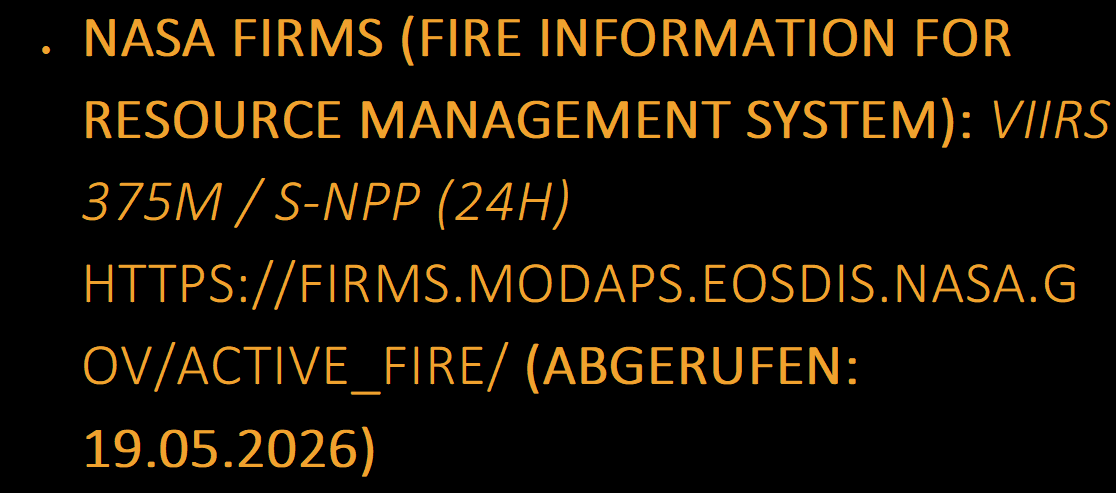